# 08 — Local Inference & Model Export

 **Purpose:** Define reusable inference functions, generate classifier-ready outputs,
 run timing tests, and export TorchScript + ONNX.

 **This notebook does NOT:** train or use diabetes images.

# 1  Imports

In [1]:
import os, time, shutil, random
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as TF

In [3]:
import segmentation_models_pytorch as smp
from pathlib import Path
from PIL import Image
print(f"torch {torch.__version__}  |  smp {smp.__version__}  |  CUDA {torch.cuda.is_available()}")

torch 2.6.0+cu124  |  smp 0.5.0  |  CUDA True


# 2  Constants

In [4]:
OUTPUT_ROOT   = Path(r"D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs")
TEST_MANIFEST = OUTPUT_ROOT / "03_splits" / "segmentation_test_manifest.csv"
BEST_CKPT     = OUTPUT_ROOT / "05_training_runs" / "checkpoints" / "best_efficientnetb0_unet.pth"

IMG_SIZE      = 384
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD     = 0.5
TIMING_N      = 20     # images for timing benchmark
SEED          = 42

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

assert BEST_CKPT.exists(),     f"Checkpoint not found: {BEST_CKPT} — run Notebook 6 first."
assert TEST_MANIFEST.exists(), f"Test manifest not found: {TEST_MANIFEST}"
print(f"Device    : {DEVICE}")
print(f"Checkpoint: {BEST_CKPT.name}")

Device    : cuda
Checkpoint: best_efficientnetb0_unet.pth


# 3  Create Output Directories

In [5]:
EXPORT_DIR   = OUTPUT_ROOT / "08_exported_models"
INFER_DIR    = OUTPUT_ROOT / "06_predictions" / "inference_examples"
REPORTS_DIR  = OUTPUT_ROOT / "07_reports"
AUDIT_DIR    = OUTPUT_ROOT / "04_visual_audits"

for d in [EXPORT_DIR, INFER_DIR, REPORTS_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"Ready: {d}")

Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\08_exported_models
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\inference_examples
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\07_reports
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits


# 4  Core Inference Functions

In [6]:
def load_segmentation_model(checkpoint_path: Path, device: torch.device) -> torch.nn.Module:
    """
    Load EfficientNet-B0 U-Net from a saved checkpoint.
    Returns model in eval mode on the specified device.
    Model outputs raw logits — sigmoid applied downstream.
    """
    m = smp.Unet(
        encoder_name   ="efficientnet-b0",
        encoder_weights=None,
        in_channels    =3,
        classes        =1,
        activation     =None,
    ).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    print(f"Model loaded — epoch {ckpt['epoch']}  val_dice={ckpt['val_dice']:.4f}")
    return m


def preprocess_image(image_path: str, img_size: int = 384) -> torch.Tensor:
    """
    Load an RGB image, resize to img_size × img_size, apply ImageNet normalization.
    Returns float32 tensor [1, 3, img_size, img_size] ready for model input.
    Original image dimensions are not stored here — use PIL for that separately.
    """
    img = Image.open(image_path).convert("RGB")
    img = TF.resize(img, [img_size, img_size], interpolation=TF.InterpolationMode.BILINEAR)
    t   = TF.to_tensor(img)
    t   = TF.normalize(t, IMAGENET_MEAN, IMAGENET_STD)
    return t.unsqueeze(0)   # [1,3,H,W]


def predict_mask(model: torch.nn.Module,
                 image_tensor: torch.Tensor,
                 device: torch.device,
                 threshold: float = 0.5):
    """
    Run forward pass and return:
        prob_mask  : numpy float32 [H,W]  values in [0,1]
        binary_mask: numpy uint8   [H,W]  values in {0, 255}
    Sigmoid applied here — NOT inside model.
    """
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        logits = model(image_tensor)        # [1,1,H,W] raw logits
        probs  = torch.sigmoid(logits)      # sigmoid applied here
        binary = (probs >= threshold).float()

    prob_mask   = probs[0, 0].cpu().numpy().astype("float32")
    binary_mask = (binary[0, 0].cpu().numpy() * 255).astype("uint8")
    return prob_mask, binary_mask


def create_black_background_tongue(original_image: np.ndarray,
                                   binary_mask: np.ndarray) -> np.ndarray:
    """
    Zero out all pixels outside the tongue mask.
    original_image : [H, W, 3] uint8  (at original resolution)
    binary_mask    : [H, W]    uint8  {0, 255}  (at original resolution)
    Returns [H, W, 3] uint8 with background = 0.
    """
    assert original_image.shape[:2] == binary_mask.shape, (
        "Image and mask must have the same spatial dimensions. "
        "Resize mask to original image size before calling this function."
    )
    out = original_image.copy()
    out[binary_mask == 0] = 0
    return out


def crop_to_mask_bbox(image: np.ndarray, mask: np.ndarray):
    """
    Compute the bounding box of the non-zero mask region and crop both
    image and mask to that bounding box.
    Returns (cropped_image, cropped_mask, bbox_tuple).
    bbox_tuple = (y_min, y_max, x_min, x_max).
    If mask is entirely zero, returns originals unchanged with bbox=None.
    """
    rows = np.any(mask > 0, axis=1)
    cols = np.any(mask > 0, axis=0)
    if not rows.any():
        return image, mask, None
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    y_max += 1; x_max += 1   # make slice end-exclusive
    return image[y_min:y_max, x_min:x_max], mask[y_min:y_max, x_min:x_max], (y_min, y_max, x_min, x_max)


def run_single_image_inference(image_path: str,
                                model: torch.nn.Module,
                                device: torch.device,
                                save_dir: Path,
                                img_size: int = 384,
                                threshold: float = 0.5,
                                keep_largest: bool = True):
    """
    Full pipeline for a single image:
      1. Preprocess → tensor
      2. Predict → prob_mask, binary_mask (at img_size)
      3. Optionally keep only the largest connected component
      4. Resize binary mask back to original image size
      5. Generate classifier-ready outputs:
           - binary mask PNG
           - black-background tongue image
           - bounding-box cropped tongue image
           - cropped + masked tongue image
      6. Save all outputs to save_dir

    Returns dict of output paths.
    """
    stem     = Path(image_path).stem
    orig_pil = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_pil.size
    orig_arr = np.array(orig_pil)

    # Preprocess & predict
    tensor       = preprocess_image(image_path, img_size)
    prob_mask, binary_mask_384 = predict_mask(model, tensor, device, threshold)

    # Optional: keep largest connected component
    if keep_largest:
        binary_mask_384 = _keep_largest_component(binary_mask_384)

    # Resize binary mask back to original image size
    mask_pil_orig = Image.fromarray(binary_mask_384).resize(
        (orig_w, orig_h), resample=Image.NEAREST)
    mask_orig_arr = np.array(mask_pil_orig)

    # Classifier-ready outputs
    black_bg  = create_black_background_tongue(orig_arr, mask_orig_arr)
    crop_img, crop_mask, bbox = crop_to_mask_bbox(orig_arr, mask_orig_arr)
    crop_masked = create_black_background_tongue(crop_img, crop_mask)

    # Save
    save_dir.mkdir(parents=True, exist_ok=True)
    paths = {}

    p = save_dir / f"{stem}_binary_mask.png"
    Image.fromarray(mask_orig_arr).save(str(p)); paths["binary_mask"] = str(p)

    p = save_dir / f"{stem}_black_bg.png"
    Image.fromarray(black_bg).save(str(p)); paths["black_bg"] = str(p)

    p = save_dir / f"{stem}_bbox_crop.png"
    Image.fromarray(crop_img).save(str(p)); paths["bbox_crop"] = str(p)

    p = save_dir / f"{stem}_crop_masked.png"
    Image.fromarray(crop_masked).save(str(p)); paths["crop_masked"] = str(p)

    return paths, prob_mask, mask_orig_arr


def _keep_largest_component(binary_mask: np.ndarray) -> np.ndarray:
    """
    Keep only the largest connected component in a binary mask.
    Falls back gracefully to returning the original mask if scipy is unavailable.
    binary_mask: uint8 [H,W] with values {0, 255}.
    """
    try:
        from scipy.ndimage import label as scipy_label
        labeled, n = scipy_label(binary_mask > 0)
        if n == 0:
            return binary_mask
        sizes   = [(labeled == i).sum() for i in range(1, n+1)]
        largest = np.argmax(sizes) + 1
        out     = (labeled == largest).astype("uint8") * 255
        return out
    except ImportError:
        # scipy not available — skip component filtering
        return binary_mask


print("Inference functions defined:")
print("  load_segmentation_model()")
print("  preprocess_image()")
print("  predict_mask()")
print("  create_black_background_tongue()")
print("  crop_to_mask_bbox()")
print("  run_single_image_inference()")

Inference functions defined:
  load_segmentation_model()
  preprocess_image()
  predict_mask()
  create_black_background_tongue()
  crop_to_mask_bbox()
  run_single_image_inference()


# 5  Load Model

In [7]:
model = load_segmentation_model(BEST_CKPT, DEVICE)

Model loaded — epoch 40  val_dice=0.9935


# 6  Run Inference on 20 Random Test Images + Save Outputs

In [8]:
test_df    = pd.read_csv(TEST_MANIFEST)
sample_df  = test_df.sample(n=min(20, len(test_df)), random_state=SEED).reset_index(drop=True)

infer_records = []

for _, row in sample_df.iterrows():
    paths, prob_mask, mask_arr = run_single_image_inference(
        image_path  =row["image_path"],
        model       =model,
        device      =DEVICE,
        save_dir    =INFER_DIR,
        img_size    =IMG_SIZE,
        threshold   =THRESHOLD,
        keep_largest=True,
    )
    infer_records.append({
        "sample_id"  : row["sample_id"],
        "image_path" : row["image_path"],
        **paths,
    })

print(f"Inference complete for {len(infer_records)} images.")
print(f"Outputs saved to -> {INFER_DIR}")

Inference complete for 20 images.
Outputs saved to -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\inference_examples


# 7  Inference Timing Benchmark

In [9]:
timing_images  = sample_df["image_path"].tolist()[:TIMING_N]
timings_ms     = []

model.eval()
with torch.no_grad():
    for ip in timing_images:
        t   = preprocess_image(ip, IMG_SIZE).to(DEVICE)
        # Warmup on first image
        if len(timings_ms) == 0:
            _ = model(t)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        t0  = time.perf_counter()
        _   = model(t)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1  = time.perf_counter()
        timings_ms.append((t1 - t0) * 1000)

mean_ms = np.mean(timings_ms)
std_ms  = np.std(timings_ms)
print(f"Timing over {len(timings_ms)} images on {DEVICE}:")
print(f"  Mean : {mean_ms:.2f} ms/image")
print(f"  Std  : {std_ms:.2f} ms/image")
print(f"  Min  : {min(timings_ms):.2f} ms")
print(f"  Max  : {max(timings_ms):.2f} ms")

Timing over 20 images on cuda:
  Mean : 5.82 ms/image
  Std  : 0.32 ms/image
  Min  : 5.57 ms
  Max  : 7.08 ms


# 8  Export: TorchScript

In [10]:
TORCHSCRIPT_PATH = EXPORT_DIR / "efficientnetb0_unet_tongue_segmentation_torchscript.pt"
ts_error = None

try:
    model.eval()
    dummy  = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    traced = torch.jit.trace(model, dummy)
    traced.save(str(TORCHSCRIPT_PATH))
    # Verify round-trip
    loaded_ts = torch.jit.load(str(TORCHSCRIPT_PATH), map_location=DEVICE)
    with torch.no_grad():
        out_ts = loaded_ts(dummy)
    assert out_ts.shape == (1, 1, IMG_SIZE, IMG_SIZE), f"TorchScript output shape mismatch: {out_ts.shape}"
    print(f"TorchScript export SUCCESS -> {TORCHSCRIPT_PATH}")
    print(f"  Output shape verified: {out_ts.shape}")
except Exception as e:
    ts_error = str(e)
    print(f"TorchScript export FAILED: {e}")

TorchScript export SUCCESS -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\08_exported_models\efficientnetb0_unet_tongue_segmentation_torchscript.pt
  Output shape verified: torch.Size([1, 1, 384, 384])


# 9  Export: ONNX

In [14]:
ONNX_PATH  = EXPORT_DIR / "efficientnetb0_unet_tongue_segmentation.onnx"
onnx_error = None

try:
    import onnx
    model.eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device="cpu")
    model_cpu = model.cpu()

    torch.onnx.export(
        model_cpu,
        dummy,
        str(ONNX_PATH),
        opset_version   =12,
        input_names     =["image"],
        output_names    =["logits"],
        dynamic_axes    ={"image":  {0: "batch_size"},
                          "logits": {0: "batch_size"}},
        do_constant_folding=True,
    )
    onnx_model = onnx.load(str(ONNX_PATH))
    onnx.checker.check_model(onnx_model)
    model = model.to(DEVICE)   # restore device
    print(f"ONNX export SUCCESS -> {ONNX_PATH}")

except ImportError:
    onnx_error = "onnx package not installed. Install with: pip install onnx"
    print(f"ONNX export SKIPPED: {onnx_error}")
    model = model.to(DEVICE)
except Exception as e:
    onnx_error = str(e)
    print(f"ONNX export FAILED: {e}")
    model = model.to(DEVICE)


C:\Users\CompuMark\AppData\Roaming\Python\Python313\site-packages\torch\onnx\_internal\jit_utils.py:308: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
C:\Users\CompuMark\AppData\Roaming\Python\Python313\site-packages\torch\onnx\utils.py:657: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_graph_shape_type_inference(
C:\Users\CompuMark\AppData\Roaming\Python\Python313\site-packages\torch\onnx\utils.py:1127: UserWarning: Constant folding - Only steps=1 can be constant folded for opse

ONNX export SUCCESS -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\08_exported_models\efficientnetb0_unet_tongue_segmentation.onnx


# 10  Save Inference & Export Report

In [15]:
REPORT_PATH = REPORTS_DIR / "08_local_inference_export_report.txt"

lines = [
    "=" * 60,
    "LOCAL INFERENCE & EXPORT REPORT — EfficientNet-B0 U-Net",
    "=" * 60,
    f"  Checkpoint      : {BEST_CKPT.name}",
    f"  Device          : {DEVICE}",
    f"  IMG_SIZE        : {IMG_SIZE}",
    f"  Threshold       : {THRESHOLD}",
    "-" * 60,
    "TIMING BENCHMARK",
    f"  N images        : {len(timings_ms)}",
    f"  Mean ms/image   : {mean_ms:.2f}",
    f"  Std  ms/image   : {std_ms:.2f}",
    f"  Min  ms/image   : {min(timings_ms):.2f}",
    f"  Max  ms/image   : {max(timings_ms):.2f}",
    "-" * 60,
    "EXPORTS",
    f"  TorchScript     : {'SUCCESS — ' + str(TORCHSCRIPT_PATH) if ts_error is None else 'FAILED — ' + str(ts_error)}",
    f"  ONNX            : {'SUCCESS — ' + str(ONNX_PATH) if onnx_error is None else 'SKIPPED/FAILED — ' + str(onnx_error)}",
    "-" * 60,
    "INFERENCE OUTPUTS PER IMAGE",
    "  binary_mask.png   — binary {0,255} at original resolution",
    "  black_bg.png      — tongue on black background",
    "  bbox_crop.png     — bounding-box crop of original",
    "  crop_masked.png   — bounding-box crop with background zeroed",
    "=" * 60,
]
text = "\n".join(lines)
print(text)
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(text + "\n")
print(f"\nReport saved -> {REPORT_PATH}")


LOCAL INFERENCE & EXPORT REPORT — EfficientNet-B0 U-Net
  Checkpoint      : best_efficientnetb0_unet.pth
  Device          : cuda
  IMG_SIZE        : 384
  Threshold       : 0.5
------------------------------------------------------------
TIMING BENCHMARK
  N images        : 20
  Mean ms/image   : 5.82
  Std  ms/image   : 0.32
  Min  ms/image   : 5.57
  Max  ms/image   : 7.08
------------------------------------------------------------
EXPORTS
  TorchScript     : SUCCESS — D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\08_exported_models\efficientnetb0_unet_tongue_segmentation_torchscript.pt
  ONNX            : SUCCESS — D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\08_exported_models\efficientnetb0_unet_tongue_segmentation.onnx
------------------------------------------------------------
INFERENCE OUTPUTS PER IMAGE
  binary_mask.png   — binary {0,255} at original resolution
  black_bg.png      — tongue on black background
  bbox_crop.png     — bounding-box

# 11  Visual Grid: Local Inference Examples

 Columns: original | predicted mask | black-background tongue | bbox crop

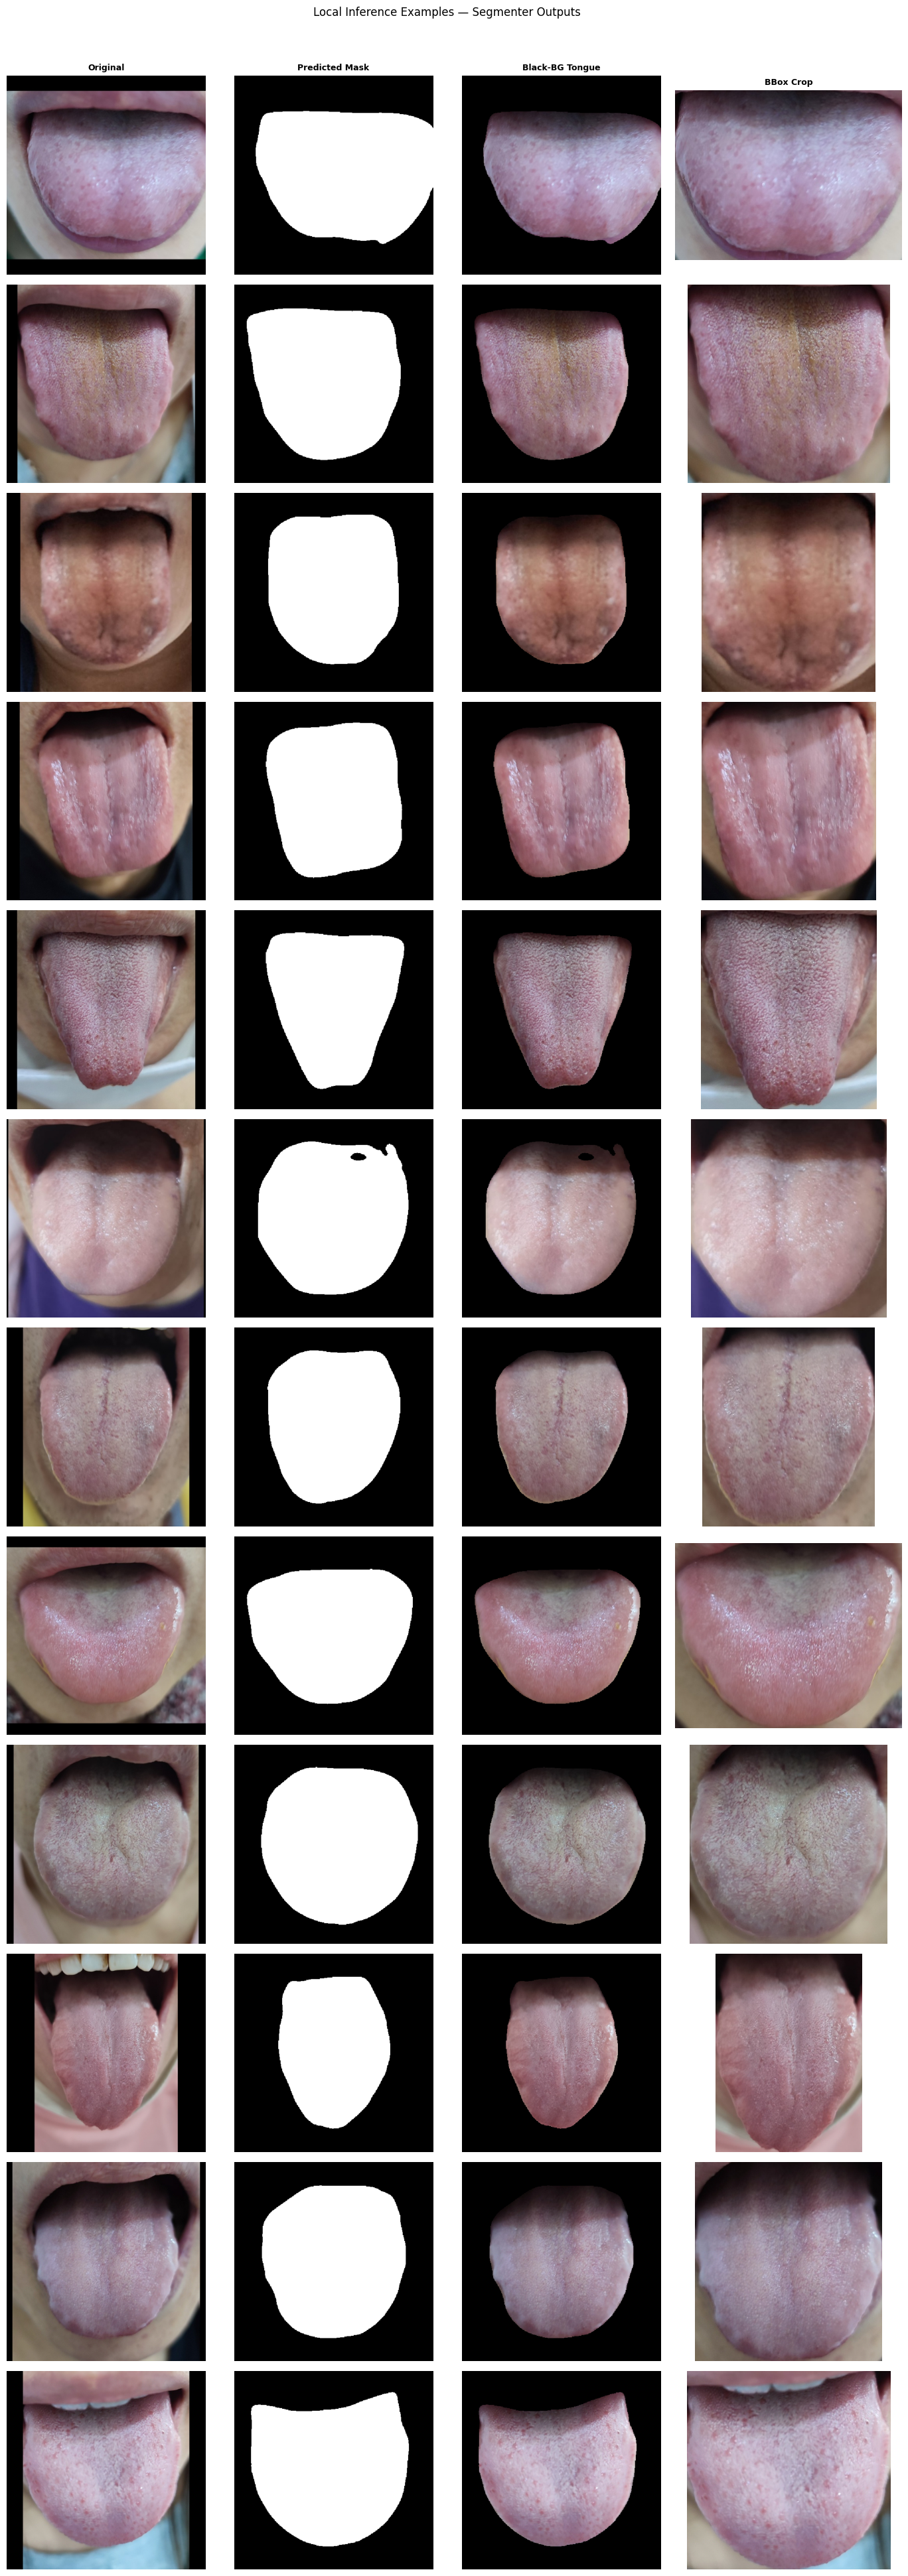

Visual grid saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\08_local_inference_examples.png


In [17]:
VISUAL_PATH = AUDIT_DIR / "08_local_inference_examples.png"

# Use the saved inference output paths
infer_df = pd.DataFrame(infer_records)
n_show   = min(12, len(infer_df))
sampled  = infer_df.sample(n=n_show, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(n_show, 4, figsize=(14, n_show*3.2), squeeze=False)
for c, h in enumerate(["Original","Predicted Mask","Black-BG Tongue","BBox Crop"]):
    axes[0,c].set_title(h, fontsize=9, fontweight="bold")

for i, row in sampled.iterrows():
    def _safe_open(path, mode="RGB"):
        try:
            return np.array(Image.open(path).convert(mode))
        except Exception:
            return np.zeros((IMG_SIZE, IMG_SIZE, 3) if mode=="RGB" else (IMG_SIZE, IMG_SIZE), dtype="uint8")

    orig    = _safe_open(row["image_path"])
    mask    = _safe_open(row["binary_mask"], "L")
    black   = _safe_open(row["black_bg"])
    crop    = _safe_open(row["bbox_crop"])

    axes[i,0].imshow(orig)
    axes[i,1].imshow(mask,   cmap="gray", vmin=0, vmax=255)
    axes[i,2].imshow(black)
    axes[i,3].imshow(crop)
    for c in range(4): axes[i,c].axis("off")
    axes[i,0].set_ylabel(row["sample_id"], fontsize=6,
                          rotation=0, labelpad=60, va="center")

fig.suptitle("Local Inference Examples — Segmenter Outputs", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(VISUAL_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Visual grid saved -> {VISUAL_PATH}")


# Notebook Complete

 | Output | Path |
 |--------|------|
 | Inference examples | `06_predictions/inference_examples/` |
 | TorchScript model  | `08_exported_models/efficientnetb0_unet_tongue_segmentation_torchscript.pt` |
 | ONNX model         | `08_exported_models/efficientnetb0_unet_tongue_segmentation.onnx` |
 | Inference report   | `07_reports/08_local_inference_export_report.txt` |
 | Visual grid        | `04_visual_audits/08_local_inference_examples.png` |

 ### Reusable functions for downstream classifier integration:
 - `load_segmentation_model()`
 - `preprocess_image()`
 - `predict_mask()`
 - `create_black_background_tongue()`
 - `crop_to_mask_bbox()`
 - `run_single_image_inference()`

 **No training performed. No diabetes images used. Segmenter is ready for integration.**